In [1]:
import sys
import sys, os, glob
# the chapter programs live in BookPrograms/chapterNN; put them all on the path
for _d in sorted(glob.glob(os.path.join("..", "BookManybody",
                                        "BookPrograms", "chapter*"))):
    if _d not in sys.path:
        sys.path.insert(0, _d)

import math
import numpy as np
import matplotlib.pyplot as plt

import dmc
from vmc import TAUT_ENERGY, vmc_importance

plt.rcParams["figure.figsize"] = (7.0, 4.2)
print("exact (Taut)      ", TAUT_ENERGY)
print("VMC (chapter 14)  ", dmc.E_VMC)
print("guiding function  alpha =", dmc.ALPHA_OPT, " beta =", dmc.BETA_OPT)

exact (Taut)       3.0
VMC (chapter 14)   3.000549
guiding function  alpha = 1.0  beta = 0.4


In [2]:
naive = dmc.naive_dmc_harmonic(n_steps=3000)
print(f"E = {naive['energy']:.6f} +/- {naive['error']:.6f}   (exact {naive['exact']})")

E = 0.497322 +/- 0.002792   (exact 0.5)


In [3]:
result = dmc.dmc(n_walkers=500, n_steps=4000, time_step=0.05,
                 rng=np.random.default_rng(2024))
print(f"acceptance        {result['acceptance']:.1%}")
print(f"mean population   {result['mean_population']:.0f}")
print(f"var(E_L)          {result['variance']:.5f}")
print(f"correlation time  {result['tau']:.2f}")
print()
print(f"mixed estimator   E = {result['energy']:.6f} +/- {result['error']:.6f}")
print(f"growth estimator  E = {result['growth']:.6f} +/- {result['growth_error']:.6f}")
print(f"exact                 {TAUT_ENERGY:.6f}")

acceptance        99.5%
mean population   500
var(E_L)          0.00223
correlation time  7.18

mixed estimator   E = 3.000216 +/- 0.000115
growth estimator  E = 2.999778 +/- 0.000619
exact                 3.000000


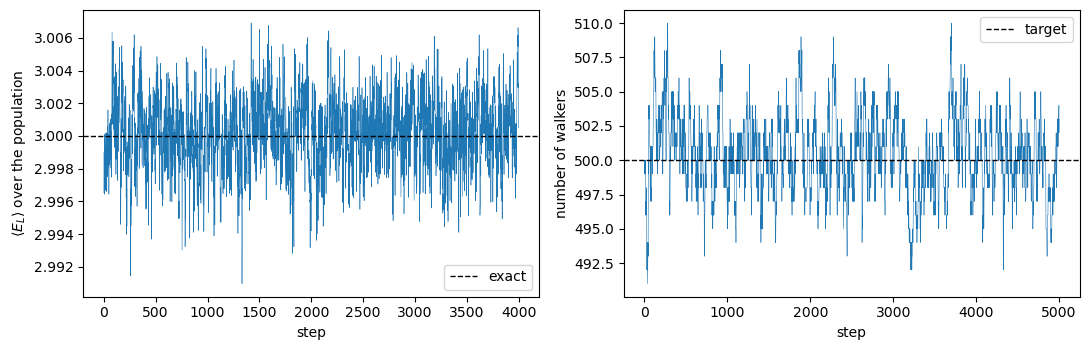

In [4]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 3.6))
left.plot(result["series"], lw=0.4)
left.axhline(TAUT_ENERGY, color="k", ls="--", lw=1, label="exact")
left.set_xlabel("step")
left.set_ylabel(r"$\langle E_L\rangle$ over the population")
left.legend()
right.plot(result["population"], lw=0.4)
right.axhline(500, color="k", ls="--", lw=1, label="target")
right.set_xlabel("step")
right.set_ylabel("number of walkers")
right.legend()
fig.tight_layout()
plt.show()

In [5]:
time_steps = [0.5, 0.3, 0.2, 0.1, 0.05, 0.02]
scans = {}
for label, use_eff in (("plain dt", False), ("dt_eff", True)):
    energies, errors = [], []
    print(label)
    print(f"{'dt':>8s} {'energy':>12s} {'error':>10s} {'accept':>8s} "
          f"{'dteff/dt':>9s} {'tau':>6s}")
    for dt in time_steps:
        out = dmc.dmc(n_walkers=500, n_steps=4000, time_step=dt,
                      effective_time_step=use_eff,
                      rng=np.random.default_rng(2024))
        energies.append(out["energy"])
        errors.append(out["error"])
        print(f"{dt:8.3f} {out['energy']:12.6f} {out['error']:10.6f} "
              f"{out['acceptance']:8.1%} "
              f"{out['effective_time_step']/dt:9.3f} {out['tau']:6.1f}")
    fit = dmc.extrapolate(time_steps, energies, errors)
    scans[label] = (np.array(energies), np.array(errors), fit)
    print(f"  extrapolated {fit['intercept']:.6f} +/- {fit['intercept_error']:.6f}"
          f"   slope {fit['coefficients'][1]:+.5f}")
    print()

plain dt
      dt       energy      error   accept  dteff/dt    tau


   0.500     2.999835   0.000050    87.2%     1.000    1.2


   0.300     2.999889   0.000057    93.6%     1.000    1.7


   0.200     2.999959   0.000068    96.4%     1.000    2.3


   0.100     3.000098   0.000089    98.6%     1.000    4.2


...

   0.300     3.000040   0.000058    93.6%     0.899    1.7


   0.200     2.999946   0.000065    96.4%     0.942    2.3


   0.100     3.000155   0.000096    98.7%     0.978    5.2


   0.050     3.000216   0.000115    99.5%     0.991    7.2


   0.020     2.999736   0.000167    99.9%     0.998   18.3
  extrapolated 3.000090 +/- 0.000094   slope -0.00031



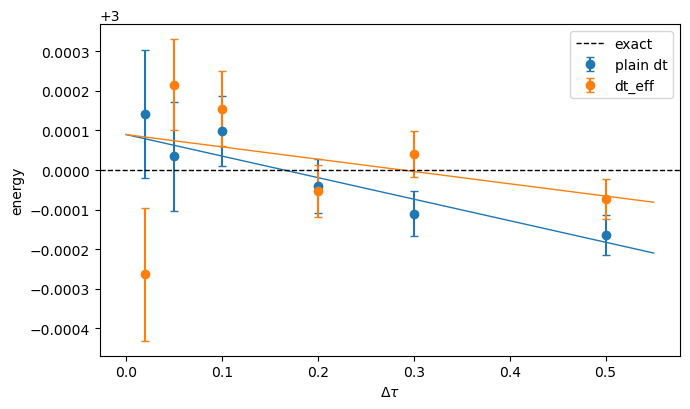

In [6]:
grid = np.linspace(0.0, 0.55, 100)
for label, (energies, errors, fit) in scans.items():
    line = plt.errorbar(time_steps, energies, yerr=errors, fmt="o", capsize=3,
                        label=label)
    plt.plot(grid, fit["coefficients"][0] + fit["coefficients"][1] * grid,
             lw=1, color=line[0].get_color())
plt.axhline(TAUT_ENERGY, color="k", ls="--", lw=1, label="exact")
plt.xlabel(r"$\Delta\tau$")
plt.ylabel("energy")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
poor_vmc = vmc_importance(0.80, 0.10, n_cycles=60000, time_step=0.5,
                          rng=np.random.default_rng(7))
print(f"VMC with the same trial function: {poor_vmc['energy']:.6f} "
      f"+/- {poor_vmc['error']:.6f}   (variance {poor_vmc['variance']:.4f})")
print()

poor_steps = [0.1, 0.05, 0.02, 0.01]
energies, errors = [], []
print(f"{'dt':>8s} {'energy':>12s} {'error':>10s} {'tau':>6s}")
for dt in poor_steps:
    out = dmc.dmc(alpha=0.80, beta=0.10, n_walkers=2000, n_steps=3000,
                  time_step=dt, rng=np.random.default_rng(2024))
    energies.append(out["energy"])
    errors.append(out["error"])
    print(f"{dt:8.3f} {out['energy']:12.6f} {out['error']:10.6f} {out['tau']:6.1f}")
poor_fit = dmc.extrapolate(poor_steps, energies, errors)
print(f"  extrapolated {poor_fit['intercept']:.6f} "
      f"+/- {poor_fit['intercept_error']:.6f}   "
      f"slope {poor_fit['coefficients'][1]:+.5f}")

VMC with the same trial function: 3.363877 +/- 0.005019   (variance 0.6227)

      dt       energy      error    tau


   0.100     3.025847   0.000966    8.0


   0.050     3.014878   0.001555   20.5


   0.020     3.002270   0.002293   52.8


   0.010     3.005206   0.002222   50.6
  extrapolated 3.001071 +/- 0.002338   slope +0.24931


In [8]:
print(f"{'walkers':>8s} {'good guide':>24s} {'poor guide':>24s}")
for n in (250, 500, 1000, 2000):
    good = dmc.dmc(n_walkers=n, n_steps=3000, time_step=0.1,
                   rng=np.random.default_rng(2024))
    bad = dmc.dmc(alpha=0.80, beta=0.10, n_walkers=n, n_steps=3000,
                  time_step=0.1, rng=np.random.default_rng(2024))
    print(f"{n:8d} {good['energy']:16.6f} +/- {good['error']:.6f} "
          f"{bad['energy']:14.6f} +/- {bad['error']:.6f}")

 walkers               good guide               poor guide


     250         2.999874 +/- 0.000131       3.024045 +/- 0.003611


     500         3.000158 +/- 0.000099       3.021299 +/- 0.002181


    1000         2.999966 +/- 0.000062       3.022742 +/- 0.001509


    2000         2.999934 +/- 0.000044       3.025847 +/- 0.000966
